1. divide my data to 5 year non-overlapping window in age (people 20-24, 25-29, 30-34 etc.)

2. Per ROI, and per age window, I want to find the slope of birth year (b1)
the regression model is:

for age_window:

GMV_ROI_1 ~ b1*birth_year

3. after calculating all b1 for all age windows, I want to present them in a plot (y axis is GMV, x axisis birth year).

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import statsmodels.formula.api as smf
from tqdm import tqdm

In [2]:
coef_df = pd.read_csv('/home/gaia/Projects/legacy_data/legacy_pipe/data/interim/coef_df_age_bins_size_5.csv')
birth_year_coef_df = coef_df[coef_df['variable'] == 'birth_year']

# Add weights to the coef according to how good the model is (how precise the the coef)
# use WLS model


In [3]:
# calculate the weight for each coef based on 

In [4]:
# Build the WLS plot for each ROI


# Visualization

Trends per ROI 

Region 421 - Coef vs Age Bin Regression Summary:
                            OLS Regression Results                            
Dep. Variable:                   coef   R-squared:                       0.108
Model:                            OLS   Adj. R-squared:                  0.027
Method:                 Least Squares   F-statistic:                     1.330
Date:                Wed, 04 Feb 2026   Prob (F-statistic):              0.273
Time:                        16:56:28   Log-Likelihood:                -36.753
No. Observations:                  13   AIC:                             77.51
Df Residuals:                      11   BIC:                             78.64
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
I

/tmp/ipykernel_20162/1460393156.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  birth_year_coef_df['age_bin_interval'] = birth_year_coef_df['age_bin'].apply(string_to_interval)
/tmp/ipykernel_20162/1460393156.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  birth_year_coef_df['mid_age_bin'] = birth_year_coef_df['age_bin_interval'].apply(lambda x: x.mid)
/home/gaia/Projects/legacy_data/venv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be i

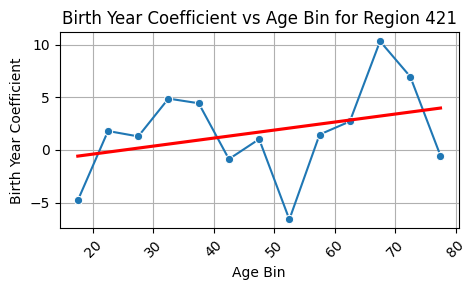

Region 422 - Coef vs Age Bin Regression Summary:
                            OLS Regression Results                            
Dep. Variable:                   coef   R-squared:                       0.174
Model:                            OLS   Adj. R-squared:                  0.099
Method:                 Least Squares   F-statistic:                     2.322
Date:                Wed, 04 Feb 2026   Prob (F-statistic):              0.156
Time:                        16:56:28   Log-Likelihood:                -43.017
No. Observations:                  13   AIC:                             90.03
Df Residuals:                      11   BIC:                             91.16
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
I

/home/gaia/Projects/legacy_data/venv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=13 observations were given.
  return hypotest_fun_in(*args, **kwds)


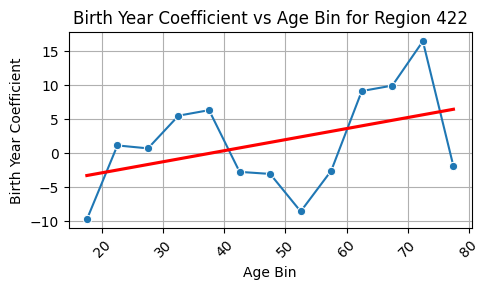

Region 448 - Coef vs Age Bin Regression Summary:
                            OLS Regression Results                            
Dep. Variable:                   coef   R-squared:                       0.125
Model:                            OLS   Adj. R-squared:                  0.045
Method:                 Least Squares   F-statistic:                     1.565
Date:                Wed, 04 Feb 2026   Prob (F-statistic):              0.237
Time:                        16:56:28   Log-Likelihood:                -38.457
No. Observations:                  13   AIC:                             80.91
Df Residuals:                      11   BIC:                             82.04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
I

/home/gaia/Projects/legacy_data/venv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=13 observations were given.
  return hypotest_fun_in(*args, **kwds)


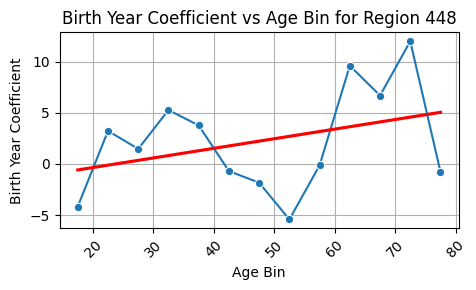

Region 449 - Coef vs Age Bin Regression Summary:
                            OLS Regression Results                            
Dep. Variable:                   coef   R-squared:                       0.064
Model:                            OLS   Adj. R-squared:                 -0.021
Method:                 Least Squares   F-statistic:                    0.7551
Date:                Wed, 04 Feb 2026   Prob (F-statistic):              0.403
Time:                        16:56:28   Log-Likelihood:                -41.681
No. Observations:                  13   AIC:                             87.36
Df Residuals:                      11   BIC:                             88.49
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
I

/home/gaia/Projects/legacy_data/venv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=13 observations were given.
  return hypotest_fun_in(*args, **kwds)


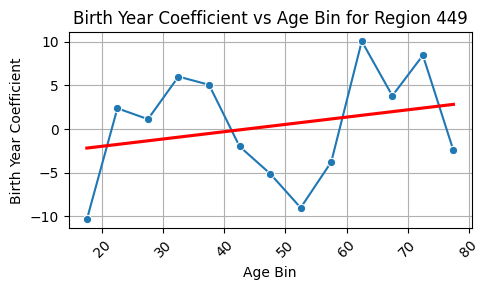

In [5]:
# Function to convert the string "(20, 25]" into an Interval object
def string_to_interval(interval_str):
    if pd.isna(interval_str):
        return None
    # Remove brackets/parentheses and split by comma
    left, right = interval_str.strip("()[]").split(",")
    return pd.Interval(float(left), float(right), closed='right')

# 1. Convert strings to Interval objects
birth_year_coef_df['age_bin_interval'] = birth_year_coef_df['age_bin'].apply(string_to_interval)

birth_year_coef_df['mid_age_bin'] = birth_year_coef_df['age_bin_interval'].apply(lambda x: x.mid)

# plot coef vs age bin for a specific region
# all of them, list from 1 to 454
# roi_list = list(range(1, 455))
roi_list = [421,422,448,449]

for region_of_interest in roi_list:
    region_data = birth_year_coef_df[birth_year_coef_df['region_label'] == region_of_interest]
    # calculate liner regression line
    if region_data.shape[0] < 2:
        print(f"Not enough data points for region {region_of_interest} to plot.")
        continue
    model = smf.ols('coef ~ mid_age_bin', data=region_data).fit()
    print(f"Region {region_of_interest} - Coef vs Age Bin Regression Summary:")
    print(model.summary())

    # plot
    plt.figure(figsize=(5, 3))
    sns.lineplot(
        data=region_data,
        x='mid_age_bin',
        y='coef',
        marker='o'
    )
    # add the regression line 
    sns.regplot(
        data=region_data,
        x='mid_age_bin',
        y='coef',
        scatter=False,
        ci=None,
        line_kws={'color': 'red', 'label': 'Linear Fit'}
    )
    plt.title(f'Birth Year Coefficient vs Age Bin for Region {region_of_interest}')
    plt.xlabel('Age Bin')
    plt.ylabel('Birth Year Coefficient')
    plt.xticks(rotation=45)
    plt.grid()
    plt.tight_layout()
    plt.show()

Linear regression and on to the brain 
The slope of birth year in each age window 
the effect of birth year in each age window

NOTE : PROBABLY SHOWS THE STATS FROM 1 BIN ONLY, FIX THIS

Mapping 803 significant coef...
Created coef-map image for visualization.


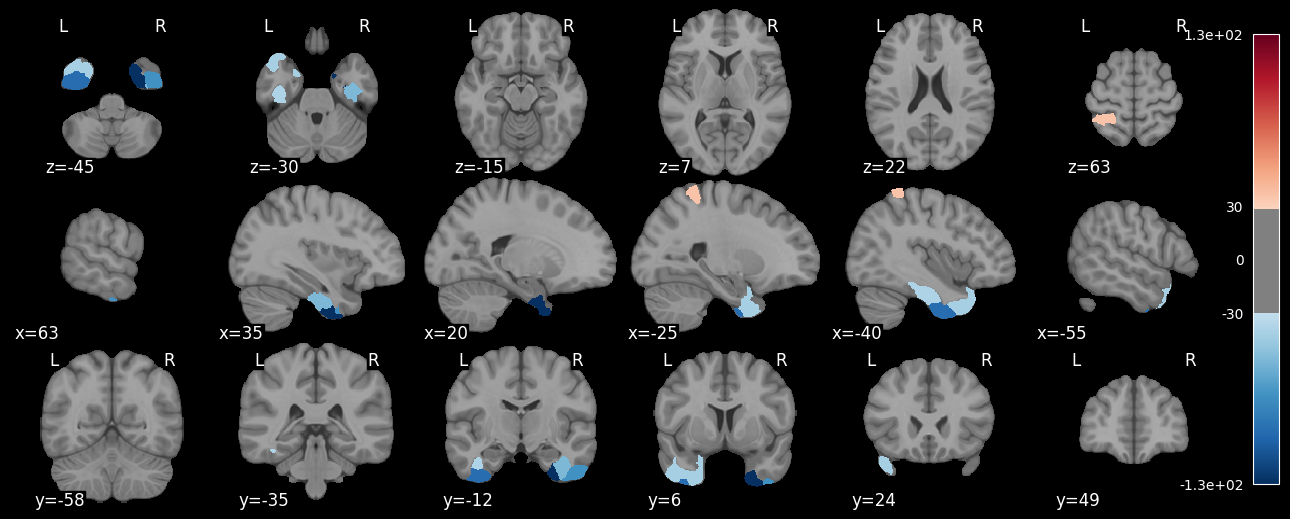

In [ ]:
# visualization of significant results on the brain, birth_year

import numpy as np
import nibabel as nib
from nilearn import plotting
from nilearn.image import new_img_like
from nilearn.datasets import load_mni152_template # for background image

# --- 1. Load Your Atlas ---
atlas_file_path = '/media/storage/MATLAB_atlases-20250612T134418Z-1-001/MATLAB_atlases/schaefer2018tian2020_400_7.nii'
atlas_img = nib.load(atlas_file_path)
atlas_labels = atlas_img.get_fdata()


# --- 2. Extract significant coefficients from your results_df ---
# THIS PROBABLY TAKES ONLYONE VALUE OF SIGNIFICENCE> FOR EXAMPLE FROM THE 20-25 BIN ONLY - FIX THIS
significant_rois_data = birth_year_coef_df[(birth_year_coef_df['fdr_p'] < 0.05)][['region_label', 'coef']].values.tolist()
# Create a dictionary for quick lookup of T-values by ROI label
coef_map = {label: coef_val for label, coef_val in significant_rois_data}


# --- 3. Create the full statistical map ---

# 1. Initialize the statistical map array to zeros.
# This ensures that all non-significant ROIs (and the background 0) are set to T=0.
stat_map_data = np.zeros_like(atlas_labels, dtype=float)

# 2. Iterate over the significant ROIs and map their T-value.
print(f"Mapping {len(significant_rois_data)} significant coef...")
for label, coef_value in coef_map.items():
    # Find all voxels in the atlas that match the current ROI label and set their value in the stat_map_data to the T-value
    stat_map_data[atlas_labels == label] = coef_value
# 3. Create the final NIfTI image for visualization.
# This ensures the coef-map has the same spatial dimensions and coordinates as your atlas.
coef_map_img = new_img_like(atlas_img, stat_map_data)
print("Created coef-map image for visualization.")


# --- 4. Load background template ---
bg_img = load_mni152_template()

# --- 5. Plot the coef-map ---
custom_cut_coords = (6,6,6)

# Plot the coef-map using the mosaic display mode
plotting.plot_stat_map(
    stat_map_img=coef_map_img,
    bg_img=bg_img,
    # title=f"ROI T-Values",
    cmap='RdBu_r',
    symmetric_cbar=True,
    threshold=30,
    display_mode='mosaic',
    cut_coords=custom_cut_coords,
    colorbar=True
)


# Display the plot
plotting.show()

In [7]:
# view_img_on_surface(coef_map_img, threshold=0.01, cmap='RdBu_r', symmetric_cbar=True)
from nilearn.plotting import view_img_on_surface
view_img_on_surface(coef_map_img, threshold=0.01, cmap='RdBu_r', symmetric_cbar=True)

ImportError: cannot import name 'view_img_on_surface' from 'nilearn.plotting' (/home/gaia/Projects/legacy_data/venv/lib/python3.12/site-packages/nilearn/plotting/__init__.py)

In [ ]:
# make a regression model for each region to see if there is a trend in coef vs age bin
trend_results = []
for region_of_interest in roi_list:
    region_data = birth_year_coef_df[birth_year_coef_df['region_label'] == region_of_interest]
    
    if region_data.shape[0] < 2:
        continue  # Skip regions with insufficient data points

    # Fit linear regression model: coef ~ mid_age_bin
    model = smf.ols('coef ~ mid_age_bin', data=region_data).fit()
    
    trend_results.append({
        'region_label': region_of_interest,
        'slope': model.params['mid_age_bin'],
        't': model.tvalues['mid_age_bin'],
        'p': model.pvalues['mid_age_bin']
    })
trend_results_df = pd.DataFrame(trend_results)
# FDR Multiple comparison correction
from statsmodels.stats.multitest import multipletests
_, fdr_p, _, _ = multipletests(trend_results_df['p'], method='fdr_bh')
trend_results_df['fdr_p'] = fdr_p
trend_results_df = trend_results_df.sort_values(by='fdr_p')
print(trend_results_df.head())

# plot the regression lines for significant regions
significant_trends = trend_results_df[trend_results_df['fdr_p'] < 0.05]
print(f"Significant trends found in regions: {significant_trends['region_label'].tolist()}")

for _, row in significant_trends.iterrows():
    region_of_interest = row['region_label']
    region_data = birth_year_coef_df[birth_year_coef_df['region_label'] == region_of_interest]
    
    plt.figure(figsize=(5, 3))
    sns.regplot(
        data=region_data,
        x='mid_age_bin',
        y='coef',
        ci=None,
        line_kws={'color': 'red'}
    )
    plt.title(f'Trend in Birth Year Coefficient vs Age Bin for Region {region_of_interest}')
    plt.xlabel('Age Bin')
    plt.ylabel('Birth Year Coefficient')
    plt.xticks(rotation=45)
    plt.grid()
    plt.tight_layout()
    plt.show()

   region_label     slope         t         p     fdr_p
0           421  0.076000  1.153316  0.273226  0.364301
1           422  0.162578  1.523828  0.155771  0.364301
2           448  0.093970  1.250847  0.236942  0.364301
3           449  0.083655  0.868978  0.403421  0.403421
Significant trends found in regions: []
